# Exploratory Data Analysis - Insurance Risk Analytics
This notebook contains EDA covering data summarization, quality assessment, univariate/bivariate analysis, and geographic trends.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/insurance_data.csv')
display(df.head())


,ZipCode,Province,Gender,VehicleMake,VehicleType,TotalPremium,TotalClaims,CustomValueEstimate,ClaimFrequency
0,25795,BC,F,Ford,Truck,1188.36,1991.78,48192.23,1
1,10860,BC,F,Honda,Sedan,1650.87,888.51,30399.36,0
2,86820,BC,M,Tesla,Sedan,1597.88,470.53,27620.56,0
3,64886,BC,M,Ford,SUV,NaN,336.57,32690.24,1
4,16265,BC,F,BMW,Truck,1471.69,227.18,32436.37,0


In [2]:
# Data Summarization & Quality Assessment
print("Data Summary:")
display(df.describe())
print("\nMissing Values:")
display(df.isnull().sum())

# Strategy for missing values:
# Drop rows with missing TotalPremium, and fill CustomValueEstimate with median.
df.dropna(subset=['TotalPremium'], inplace=True)
df['CustomValueEstimate'] = df['CustomValueEstimate'].fillna(df['CustomValueEstimate'].median())


Data Summary:


,ZipCode,TotalPremium,TotalClaims,CustomValueEstimate,ClaimFrequency
count,500.000000,490.000000,500.000000,480.000000,500.000000
mean,55825.006000,1498.633694,1025.955340,30136.493229,0.478000
std,26748.293127,302.635397,998.242235,9872.888825,0.682971
min,10206.000000,638.620000,0.010000,-3247.560000,0.000000
25%,32596.250000,1295.010000,308.592500,23122.825000,0.000000
50%,58379.000000,1509.095000,696.865000,30169.250000,0.000000
75%,77983.500000,1699.632500,1454.487500,37088.840000,1.000000
max,99912.000000,2319.260000,6128.820000,60619.470000,3.000000



Missing Values:


ZipCode                 0
Province                0
Gender                  0
VehicleMake             0
VehicleType             0
TotalPremium           10
TotalClaims             0
CustomValueEstimate    20
ClaimFrequency          0
dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_2344\3949288442.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='VehicleType', ax=axes[2], palette='pastel')


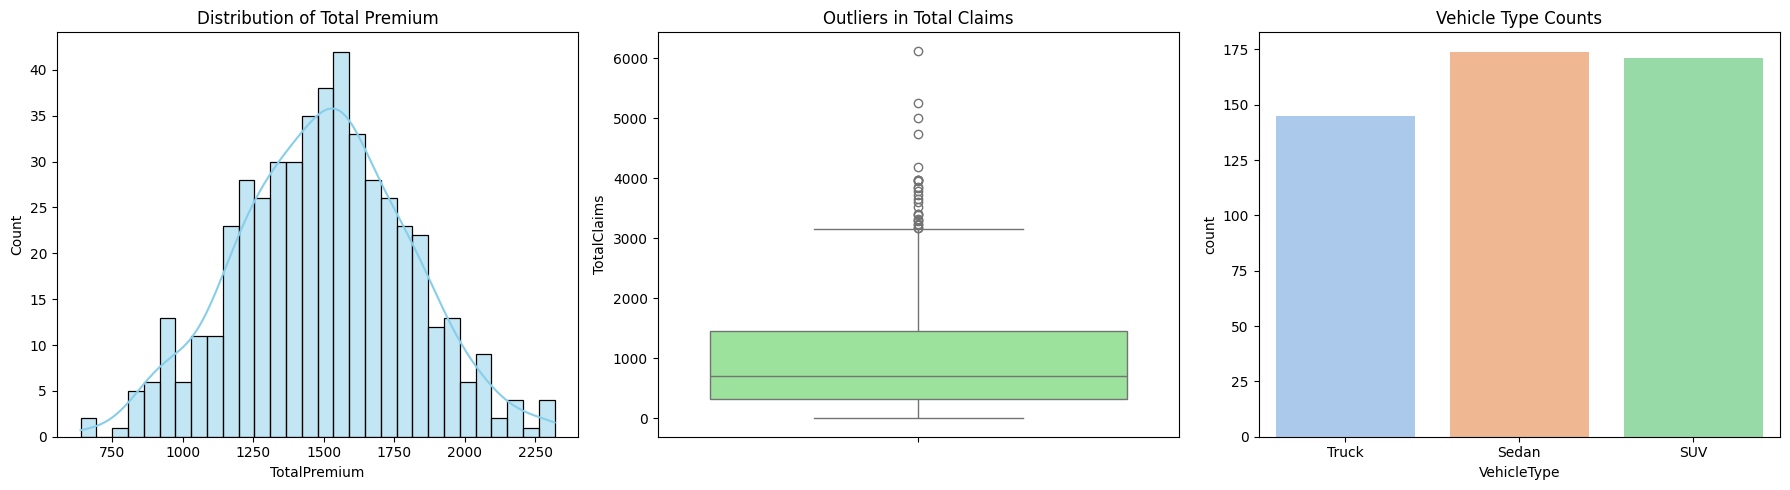

In [3]:
# Univariate Analysis & Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['TotalPremium'], bins=30, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Distribution of Total Premium')

sns.boxplot(y=df['TotalClaims'], ax=axes[1], color='lightgreen')
axes[1].set_title('Outliers in Total Claims')

sns.countplot(data=df, x='VehicleType', ax=axes[2], palette='pastel')
axes[2].set_title('Vehicle Type Counts')

plt.tight_layout()
plt.show()


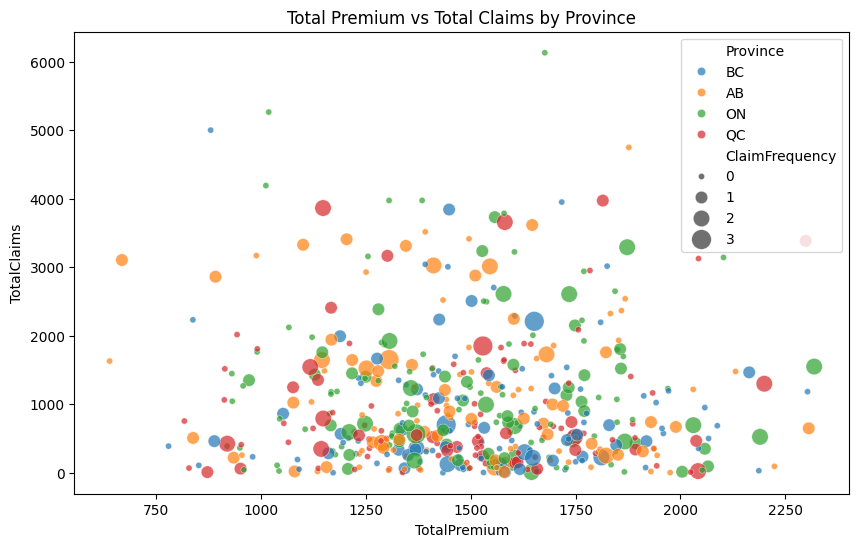

In [4]:
# Bivariate / Multivariate Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='TotalPremium', y='TotalClaims', hue='Province', size='ClaimFrequency', sizes=(20, 200), alpha=0.7)
plt.title('Total Premium vs Total Claims by Province')
plt.show()


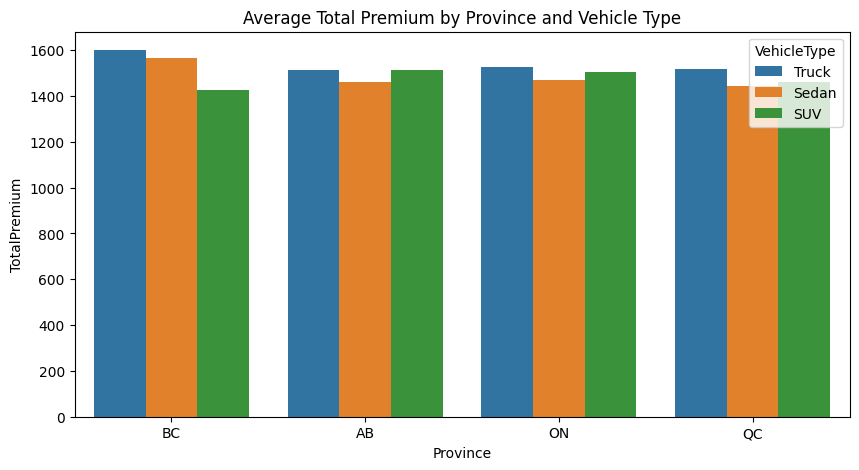

In [5]:
# Geographic Trends
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Province', y='TotalPremium', hue='VehicleType', errorbar=None)
plt.title('Average Total Premium by Province and Vehicle Type')
plt.show()


In [6]:
# Guiding Questions
# What is the overall Loss Ratio for the portfolio? How does it vary by Province, VehicleType, and Gender?
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
print("Overall Loss Ratio:", df['LossRatio'].mean())

print("\nLoss Ratio by Province:")
display(df.groupby('Province')['LossRatio'].mean())


Overall Loss Ratio: 0.7278191510188718

Loss Ratio by Province:


Province
AB    0.817988
BC    0.596792
ON    0.836256
QC    0.629494
Name: LossRatio, dtype: float64